# Maandelijkse telecom-netwerk-KPI's: datagebruik-staven met ARPU- en klantverloop-lijnen (PROC GBARLINE)

## Samenvatting

Dit notebook gebruikt **PROC GBARLINE** om een verticale staafgrafiek van maandelijks mobiel datagebruik te combineren met overlay-lijngrafieken van ARPU, klantverloop en supporttickets — het klassieke "twee-assen"-KPI-dashboard dat een telecomanalist bouwt om te zien of stijgend gebruik zich werkelijk vertaalt in omzet en klantbehoud. Het genereert inline synthetische per-abonnee-records en doorloopt vervolgens de BAR- en LINE-instructies met subgroepen, aangepaste rechterassen, referentiesymbolen en legenda's.

## Gegevensbronnen

**Dataset: `telco_kpi`** — synthetische per-abonnee-maand-records (4 maanden x 3 abonnementstypen x 8 abonnees = 96 rijen), inline gegenereerd met `call streaminit(20260531)`. Het panel wordt op 96 rijen gehouden zodat het ruim binnen de limiet van 100 waarnemingen van de niet-gelicentieerde modus blijft, waardoor elke maand en elk abonnementstype volledig gevuld blijft.

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `month`  | Char | Kalendermaandlabel (jan–apr) |
| `plan`   | Char | Abonnementstype: Prepaid, Abonnement, Familie |
| `data_gb`| Num  | Maandelijks verbruikte mobiele data, in GB (gammaverdeeld, met een lichte seizoensverhoging en langzame groei) |
| `arpu`   | Num  | Gemiddelde omzet per gebruiker, in USD (stijgt met abonnementstype en in de loop van de maanden) |
| `churn`  | Num  | Maandelijkse klantverloopvlag (0/1, Bernoulli; hoger vroeg in de periode en bij goedkopere abonnementstypen) |
| `tickets`| Num  | Geopende supporttickets (Poisson-telling) |

# Maandelijkse telecom-netwerk-KPI's met PROC GBARLINE

Telecomoperators leven en sterven met een handvol maandelijkse KPI's: hoeveel **data** abonnees verbruiken, de **ARPU** (gemiddelde omzet per gebruiker) die dat verbruik oplevert, hoeveel klanten er **opzeggen** (churn), en de **support-ticket**-belasting die daarachter schuilgaat. Deze cijfers bewegen zich op zeer verschillende schalen — gigabytes, dollars en kleine tellingen — dus het uitzetten ervan op één enkele responsas verdoezelt het verhaal.

`PROC GBARLINE` is precies hiervoor gebouwd: het tekent een verticale **staaf**grafiek tegen de linkeras en legt er een of meer **lijn**grafieken overheen tegen een onafhankelijke rechteras. In dit notebook bouwen we een gebruik-versus-omzet-dashboard en voegen we vervolgens geleidelijk abonnementsniveau-subgroepen, een aangepaste rechteras en meervoudige lijn-overlays toe.

## Stap 1 — Genereer synthetische abonnee-maand-data

De onderstaande DATA-stap bouwt een realistisch panel: 4 maanden (jan–apr) over 3 abonnementstypen (Prepaid, Abonnement, Familie) met elk 8 abonnees, voor in totaal 96 rijen. We zaaien de RNG met `call streaminit` voor reproduceerbaarheid en trekken elke KPI uit een domein-passende verdeling:

- **Datagebruik** uit een gammaverdeling met een lichte seizoensverhoging en langzame groei van maand tot maand.
- **ARPU** stijgend met abonnementstype en in de loop van de maanden, met normale ruis.
- **Klantverloop** als een Bernoulli-vlag die hoger is vroeg in de periode en bij goedkopere abonnementstypen.
- **Supporttickets** als Poisson-tellingen, iets zwaarder vroeg in het jaar.

Er worden geen externe bestanden gelezen — alles is zelfvoorzienend, en het panel van 96 rijen blijft binnen de niet-gelicentieerde grens van 100 waarnemingen, zodat elke maand en elk abonnementstype wordt weergegeven.

In [1]:
GEGEVENS telco_kpi;
    CALL streaminit(20260531);
    LENGTE month $3 plan $12;
    REEKS mname[4] $3 _temporary_
        ('Jan' 'Feb' 'Mrt' 'Apr');
    DOE mi = 1 TOT 4;
        month = mname[mi];
        /* lichte seizoensverhoging en langzame datagroei */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        DOE plan_i = 1 TOT 3;
            ALS plan_i = 1 DAN plan = 'Prepaid';
            ANDERS ALS plan_i = 2 DAN plan = 'Abonnement';
            ANDERS plan = 'Familie';
            DOE rep = 1 TOT 8;
                /* maandelijks verbruikte mobiele data (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* gemiddelde omzet per gebruiker ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* maandelijkse klantverloopvlag, hoger vroeg in het jaar */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* geopende supporttickets */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                UITVOER;
            EINDE;
        EINDE;
    EINDE;
    VERWIJDEREN mi plan_i rep season mname:;
UITVOEREN;



NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Stap 2 — Het kerndashboard: gebruiksstaven + ARPU-lijn

Dit is het klassieke `GBARLINE`-patroon. De `BAR`-instructie plot het gemiddelde maandelijkse datagebruik (`SUMVAR=data_gb TYPE=mean`), en een enkele `LINE`-instructie legt de gemiddelde ARPU over de rechteras (`STAT=mean TYPE=join`). We zetten ODS Graphics aan en geven de grafiek een titel van twee regels. `COUTLINE=` en `WIDTH=` maken de staven netjes.

                                         Maandelijks mobiel datagebruik en ARPU                                         
                                           Synthetische telecom-netwerk-KPI's                                           




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Maandelijks mobiel datagebruik en ARPU.
NOTE: Option TITLE2 changed to Synthetische telecom-netwerk-KPI's.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


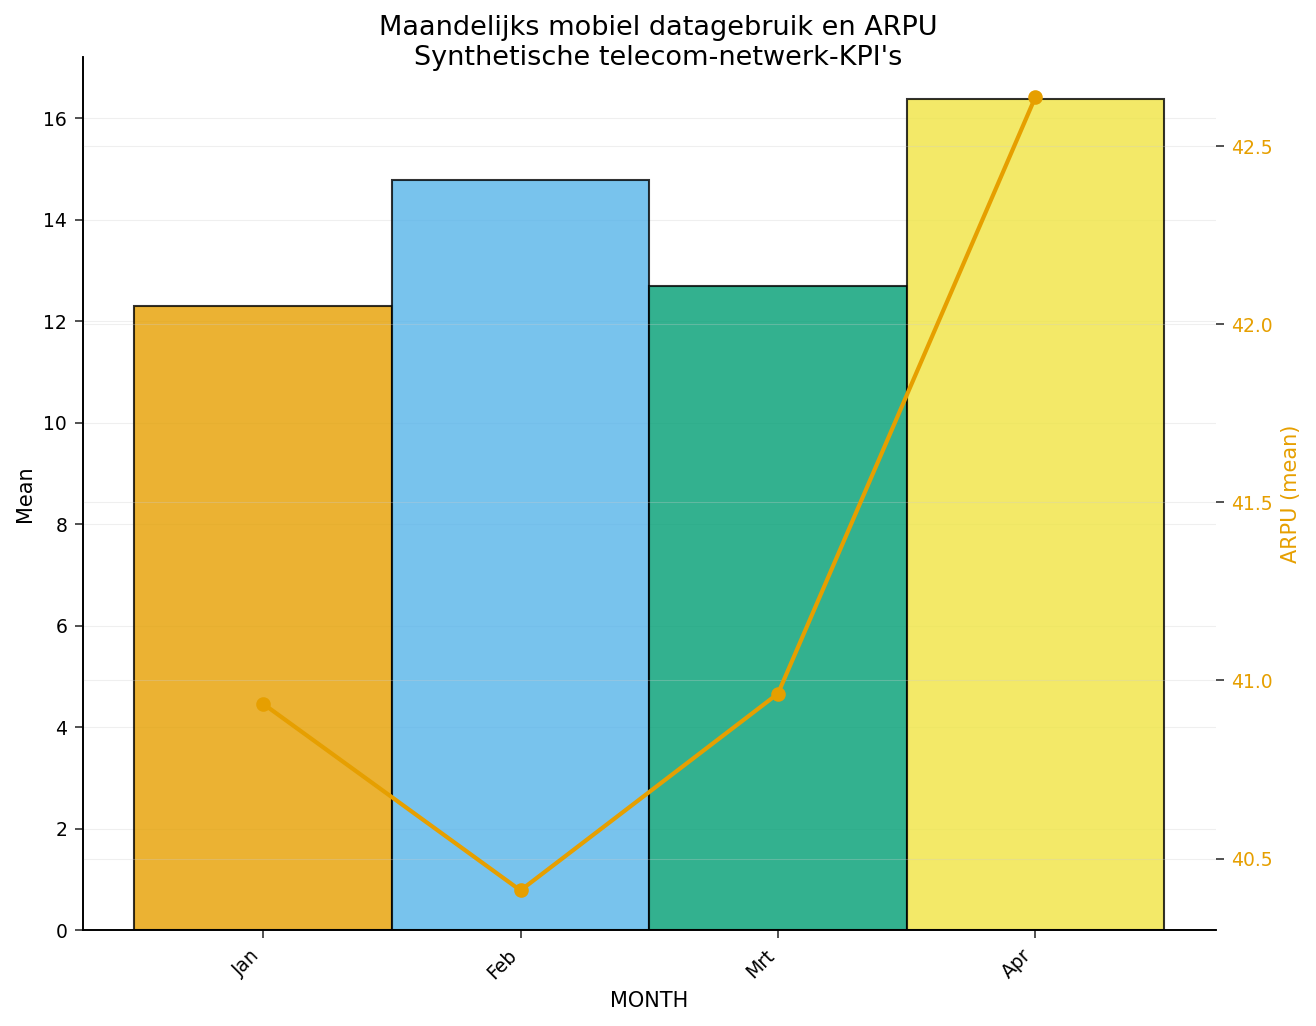

In [2]:
ODS GRAPHICS ON;
TITEL 'Maandelijks mobiel datagebruik en ARPU';
title2 "Synthetische telecom-netwerk-KPI's";

PROCEDURE gbarline GEGEVENS=telco_kpi;
    label month="Maand" data_gb="Datagebruik (GB)" arpu="ARPU (USD)";
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
UITVOEREN;


## Stap 3 — Splits gebruik uit naar abonnementstype, leg klantverloop erover

Door `TYPE=mean` te vervangen door `TYPE=sum` en `SUBGROUP=plan` toe te voegen, wordt de staaf van elke maand gestapeld per abonnementstype, zodat we kunnen zien welk segment het totale volume aanstuurt. De overgelegde `LINE` plot nu het maandelijkse **aantal** klantverloop-gebeurtenissen als een naaldplot (`STAT=sum TYPE=needle`) — verticale pieken die van nature lezen als discrete gebeurtenistellingen in plaats van een gladde trend.

                              Datavolume per abonnementstype met maandelijks klantverloop                               
                                           Synthetische telecom-netwerk-KPI's                                           




NOTE: Option TITLE changed to Datavolume per abonnementstype met maandelijks klantverloop.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


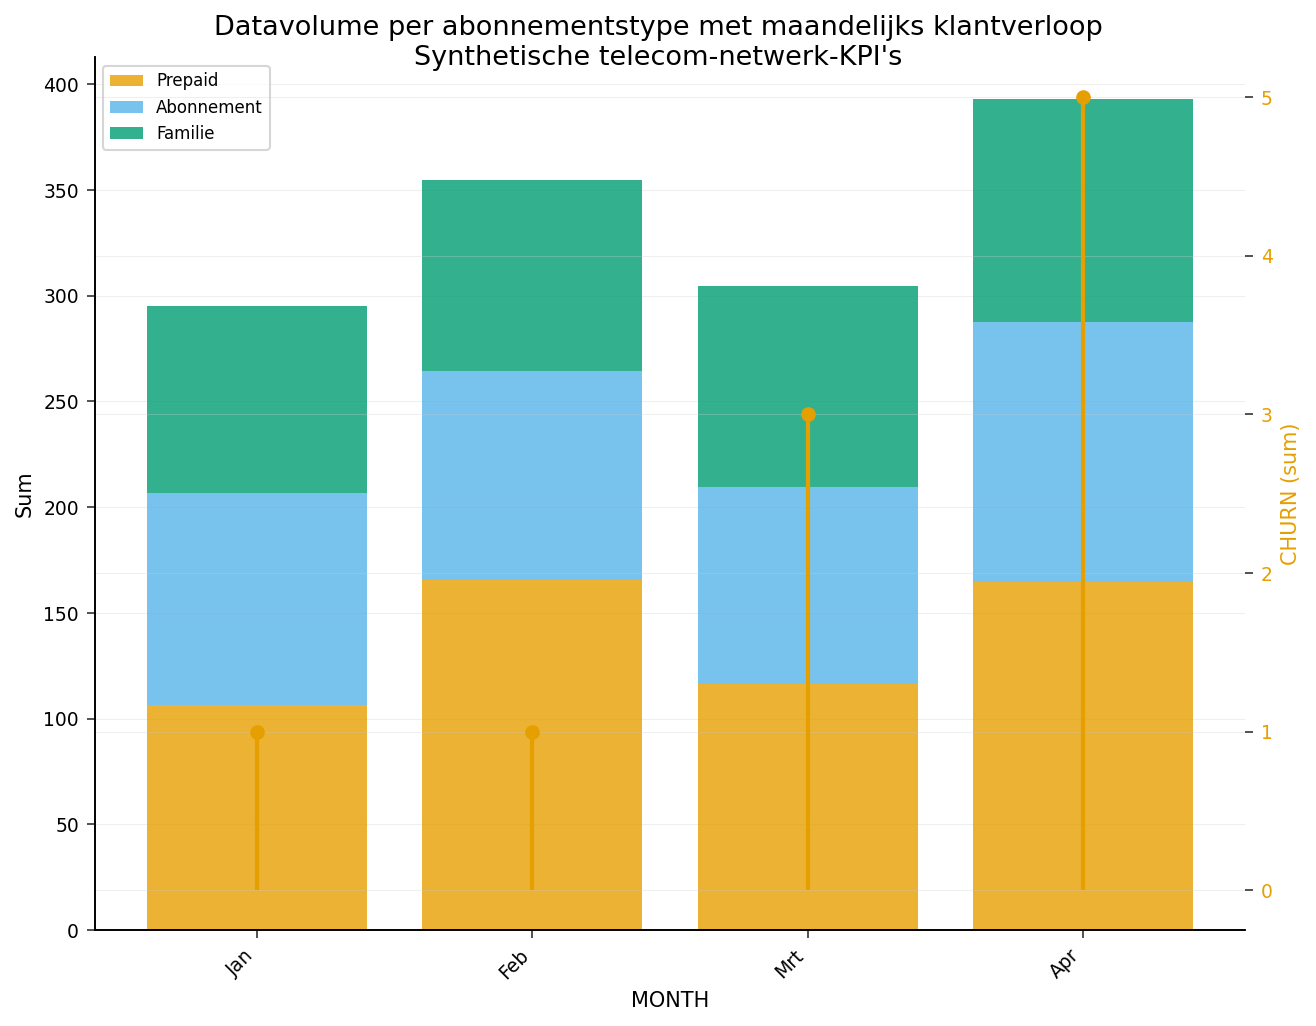

In [3]:
TITEL 'Datavolume per abonnementstype met maandelijks klantverloop';

PROCEDURE gbarline GEGEVENS=telco_kpi;
    label month="Maand" data_gb="Datagebruik (GB)" plan="Abonnementstype" churn="Klantverloop";
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
UITVOEREN;


## Stap 4 — Beheer de rechteras en de lijnmarkering

Voor een publicatieklare grafiek zetten we de plot-(rechter)as vast op een vast bereik met een `AXIS`-definitie en geven we het een label, en koppelen we het vervolgens aan de lijn via `RAXIS=axis2`. Een `SYMBOL`-definitie geeft de ARPU-lijn een rode gestippelde markering. We tonen ook de staaftotalen boven elke staaf met `OUTSIDE=sum`.

                                 Totaal gebruik (staven) versus gemiddelde ARPU (lijn)                                  
                                           Synthetische telecom-netwerk-KPI's                                           




NOTE: Option TITLE changed to Totaal gebruik (staven) versus gemiddelde ARPU (lijn).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


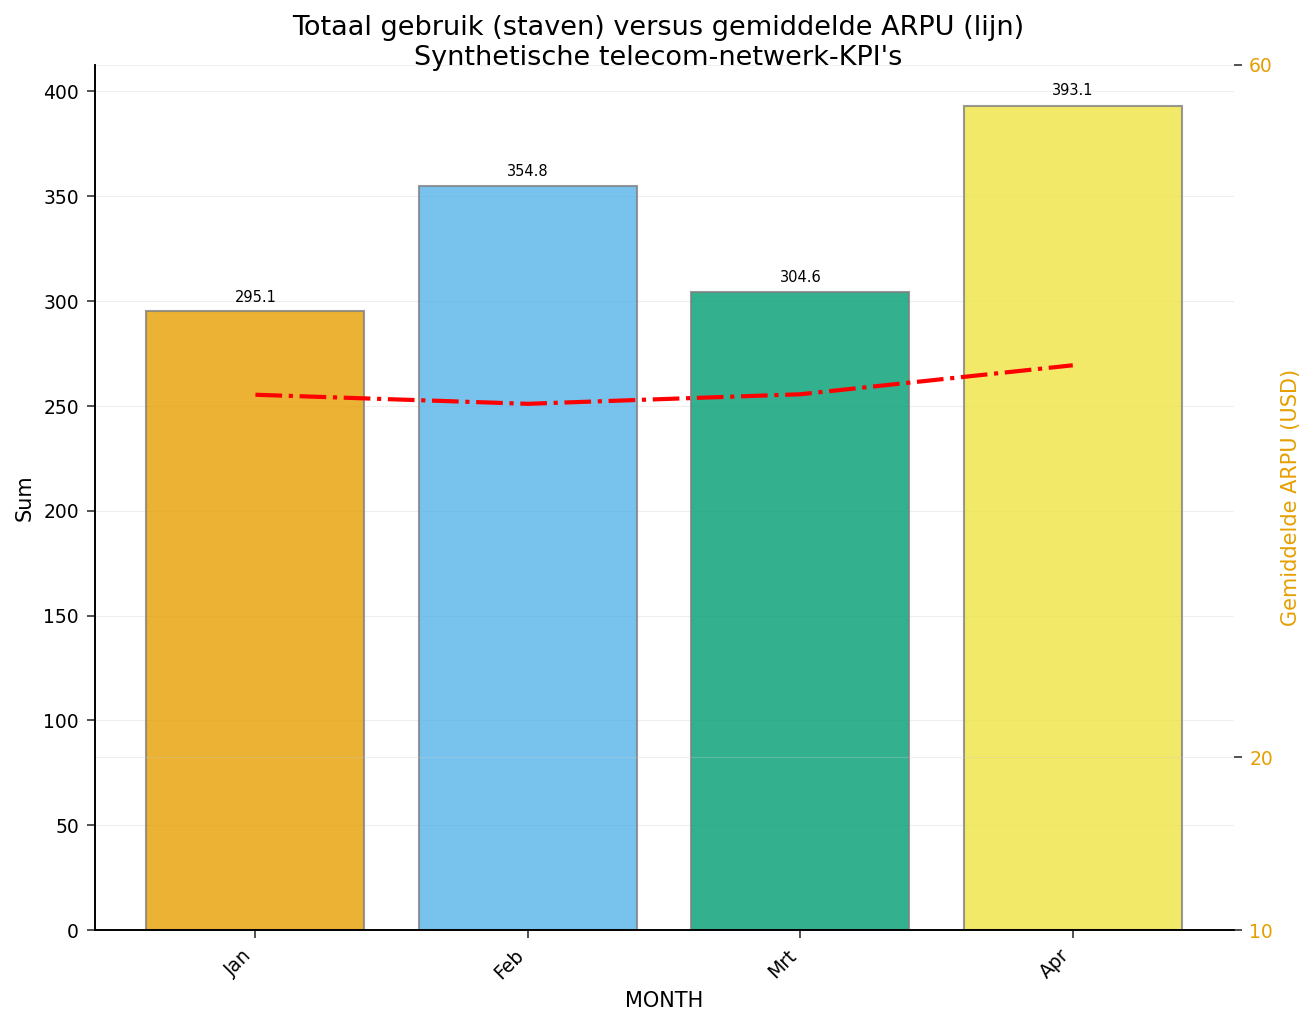

In [4]:
TITEL 'Totaal gebruik (staven) versus gemiddelde ARPU (lijn)';

PROCEDURE gbarline GEGEVENS=telco_kpi;
    label month="Maand" data_gb="Datagebruik (GB)" arpu="ARPU (USD)";
    axis2 ORDER=(20 TOT 60 VOLGENS 10) label=('Gemiddelde ARPU (USD)');
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
UITVOEREN;


## Stap 5 — Meerdere lijn-overlays met een aangepaste legenda

`GBARLINE` accepteert meer dan één `LINE`-instructie, zodat we twee operationele signalen tegelijk kunnen vergelijken met de gebruiksstaven: gemiddelde supporttickets (`type=join`) en totaal klantverloop (`type=needle`). Een `LEGEND`-definitie onderaan documenteert de abonnementstype-subgroepen.

                                        Trends in supporttickets en klantverloop                                        
                                           Synthetische telecom-netwerk-KPI's                                           




NOTE: Option TITLE changed to Trends in supporttickets en klantverloop.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


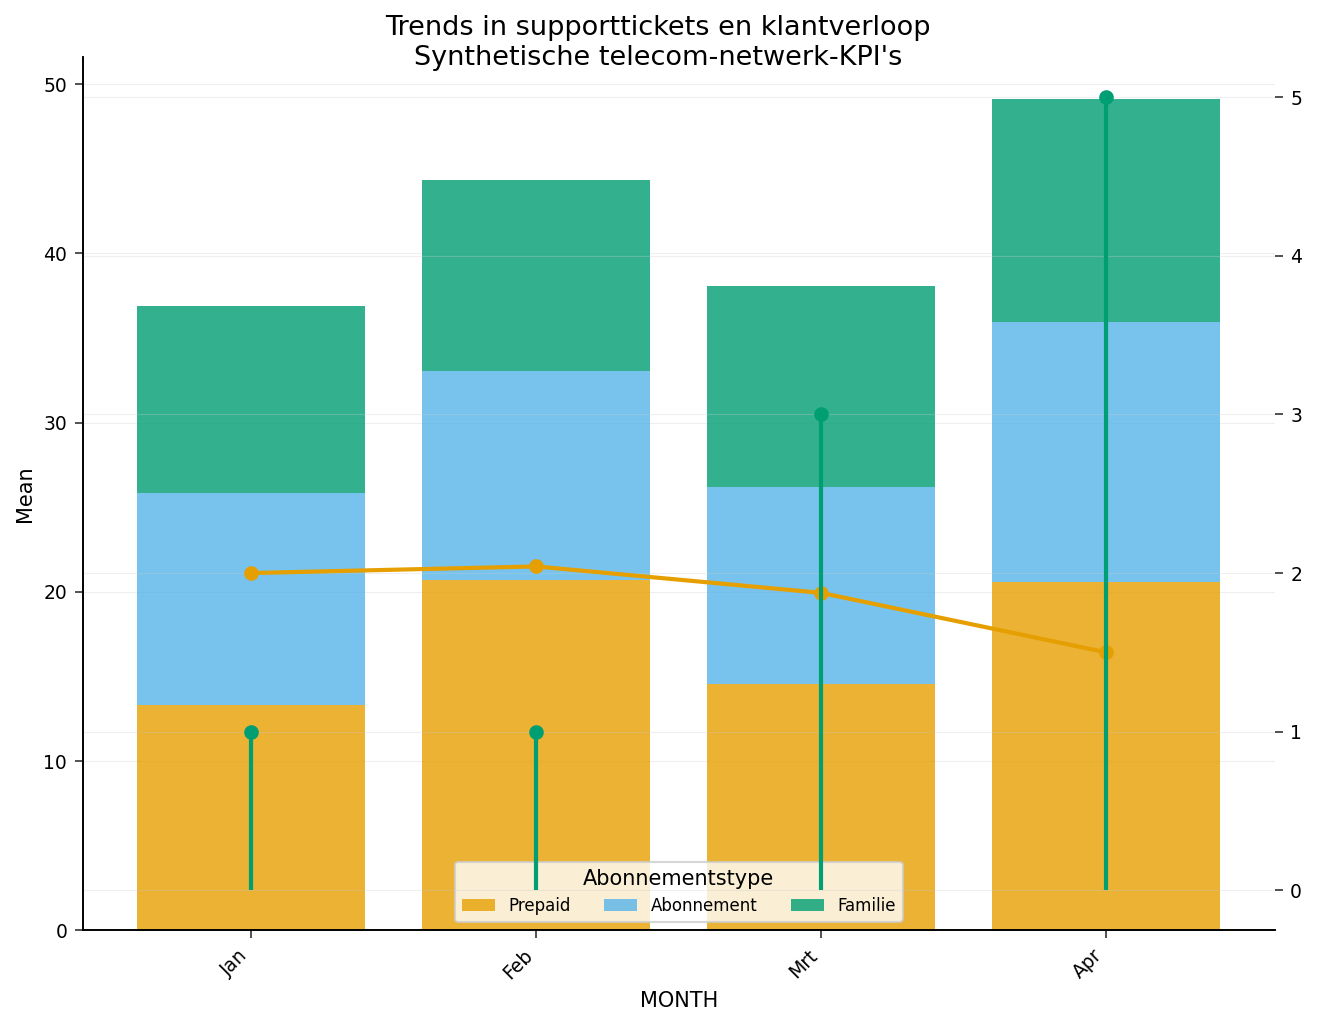

In [5]:
TITEL 'Trends in supporttickets en klantverloop';

PROCEDURE gbarline GEGEVENS=telco_kpi;
    label month="Maand" data_gb="Datagebruik (GB)" plan="Abonnementstype"
          tickets="Supporttickets" churn="Klantverloop";
    legend1 label=('Abonnementstype') position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
UITVOEREN;

ODS GRAPHICS OFF;


## Interpretatie van de resultaten

Over de periode jan–apr vertelt het dashboard een samenhangend telecomverhaal. Het **datagebruik** (de staven) is grillig van maand tot maand maar vertoont een stijgende trend, met een piek in **april** — het gemiddelde gebruik stijgt van ongeveer 12,3 GB in januari naar 16,4 GB in april (Stap 2), en het totale volume van 295 GB naar 393 GB (de `OUTSIDE=sum`-labels in Stap 4). De **ARPU-lijn** daalt licht in februari en stijgt vervolgens naar zijn eigen aprilpiek van bijna \$42,6, dus de operator verzilvert het extra verbruik steeds meer in plaats van het weg te geven — de rechteras in Stap 4 is vastgezet op \$20–\$60 om die beweging leesbaar te houden.

De per-abonnementstype-gestapelde weergaven (Stap 3 en 5) onthullen de segmentspanning die prepaid-zware operators kenmerkt. **Prepaid** (de oranje band) draagt in totaal de meeste gigabytes — ongeveer 553 GB over de vier maanden tegenover 415 GB voor Abonnement en 380 GB voor Familie — maar levert de **laagste** gemiddelde omzet per gebruiker (ongeveer \$36, tegenover \$41 voor Abonnement en \$47 voor Familie). De **klantverloop-naalden** bevestigen waar het retentierisico zit: klantverloop-gebeurtenissen clusteren zich bij Prepaid en Abonnement (elk 4 gebeurtenissen over de periode) en blijven lichter bij Familie (2), en ze nemen toe richting april naarmate de abonneebasis en het gebruik groeien.

Stap 5 legt de operationele belasting hier bovenop: gemiddelde **supporttickets** liggen iets hoger vroeg in de periode en nemen af tegen april, terwijl de klantverloop-naalden later pieken — precies het soort signaal waar een retentieteam op let. Operationeel wijst dit erop de retentie-inspanning te concentreren op **Prepaid**-abonnees, die het snelst groeiende deel van het datavolume verbruiken terwijl ze de minste omzet genereren en het meeste klantverloop veroorzaken.

`PROC GBARLINE` is hier het juiste instrument, precies omdat het de staven op gigabyte-schaal en de lijnen op dollar-/tel-schaal op onafhankelijke assen houdt, waardoor elke KPI op zijn eigen voorwaarden kan worden gelezen terwijl de maandelijkse tijdas gedeeld blijft.